Course: Diffuse and Stochastic Processes, Namiko Mitarai, NBI, University of Copenhagen

Assignment Part 1

Peter Resch, 2.6.2026

# Langevin simulation for a biased double well potential

# a) Propose a reaction scheme
should inlcude meaningful modification that change qualitative behaviour of system
briefly describe physical, biological,... motivation of model
write down equation, define vars and params
predict qualitative behaviour of mean and variance over time - increase, decrease, steady state
explain which terms could lead to this behaviour

In my simulation I am going to make a biased brownian motion in a double well potential $U(x)$. This could simulate cyclists cycling along a road, which has some curvature, is the highest in the middle and falling off on both sides - so its not easy to always ride on the highest point. No one wants to cycle next to the road in the grass, so this is also accounted for with the repellent effect of the potential far off. The bias in the random term could be seen as wind coming constantly from one side and pushing the cyclists towards one side.

The Langevin equation, which describes the position on the curvature of the street over time is
$\frac{dX}{dt}=X-\frac{1}{\eta} \frac{dU(X)}{dx}+\Delta W $,
where
$U(x)=\frac{1}{2} (x^{4} a-x^{2} b)$, therefore $\frac{dU}{dx}=2 x^{3} a-x b$ with $\langle\Delta W^{2}\rangle= 2 D \Delta t$ and $\langle\Delta W\rangle= bias $

$\eta$ is the viscosity and could be interpreted in this model as the reactiveness of steering of the cyclist.
$\Delta W$ are the random deviations of steering during cycling, combined with the wind.

My prediction without wind is, that over time the cyclists will rather be more in the valleys of the potential, sometimes switching sides, depending on how high the potential in the middle is or how strong the random term is respectively. This means, that the mean should be zero and the variance reaches a steady state, as the potential gives boundaries to the diffusion.
With the wind though, in the long run the trajectories get pushed more to one side, through which the mean should also be pushed to one side. For me it is hard to make predictions on the variance on a general case in this model, as it could be lower or higher than in the case without wind, as $Var=\langle (X-\langle X \rangle)^2 \rangle$. As the deviation far away from the mean counts more, but might be also rare, the variance is depending on the parameter values of the potential and the bias, I suspect.

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from tqdm import tqdm

r = np.random
r.seed(42)



#--------------------------------------------Functions--------------------------------------------
def brownian_movement(diffusion_coef, time_step,bias):
    return np.random.normal(bias, np.sqrt(2 * diffusion_coef * time_step))

def potential_force(x, a,b, eta):
    return -(1/eta)*(2*a * x**3 - b* x)

def next_position(current_position, d,a,b,eta, t_step,bias):
    return current_position + brownian_movement(d,t_step,bias) + potential_force(current_position, a, b, eta)* t_step

In [ ]:
#plotting histograms for different timestep values
timestep_values = [0.01, 0.1, 0.5]
numbers_drawn = 1000
brown_array = np.zeros((len(timestep_values), numbers_drawn))
for it,t_step in enumerate(timestep_values ):
    for i in tqdm(range(numbers_drawn)):
        brown_array[it,i] = brownian_movement(1, t_step,bias)#/np.sqrt(2*t_step)

fig,ax=plt.subplots(figsize=(15, 5))
for it,t_step in enumerate(timestep_values):
    ax.hist(brown_array[it,:], bins=100, density=True,range=(-4, 4), alpha=0.5, label=f'timestep={t_step}')
    x = np.linspace(-4, 4, 1000)
    ax.plot(x, stats.norm.pdf(x, 0, np.sqrt(2 * 1 * t_step)), label=f'Normal Dist. (timestep={t_step})')

  0%|          | 0/1000 [00:00<?, ?it/s]

TypeError: brownian_movement() missing 1 required positional argument: 'bias'

b) choose specific initial condition

simulate, using explicit implementation of stoch. integration method

simulate long enough to see interesting dynamics

plot 3 traj

In [3]:
#----------Initial parameters------
bias=0.4
a=1.0
b=2.0
eta=2.0
d=2
initial_position = -2.0
time_step=0.1
total_time=30

num_simulations=100



print("-----Initial parameters:---------")
print("parameter & value & unit")
print(f"bias & {bias} & N")
print(f"a & {a} & N/m$^3$")
print(f"b & {b} & N/m")
print(f"$\eta$ & {eta} & h/kg")
print(f"Diffusion coefficient & {d} & m$^2$/h")
print(f"initial position & {initial_position} & m")
print(f"time step & {time_step} & h")
print(f"total time & {total_time} & h")

print("-----------------------------------------")

-----Initial parameters:---------
parameter & value & unit
bias & 0.4 & N
a & 1.0 & N/m$^3$
b & 2.0 & N/m
$\eta$ & 2.0 & h/kg
Diffusion coefficient & 2 & m$^2$/h
initial position & -2.0 & m
time step & 0.1 & h
total time & 30 & h
-----------------------------------------


In [4]:
t_step_array=[]
for i in range(4):
    t_step_array.append(time_step/(2**i))
t_step_array=np.array(t_step_array)

num_steps = (total_time / t_step_array).astype(int)
positions = []
time_array = []

for it,t_step in enumerate(t_step_array):
    positions.append(np.zeros(( num_simulations, num_steps[it])))
    positions[it][:, 0] = initial_position
    time_array.append(np.arange(0, total_time, t_step))

#print("Starting Simulation...")
for it,t_step in enumerate(t_step_array):
    print(f"Simulating for time step: {t_step} hours")
    for i in range(num_simulations):
        print(f"\rSimulation {i+1}/{num_simulations}", end=' ')
        for j in range(1, num_steps[it]):
            positions[it][i, j] = next_position(positions[it][i, j-1], d,a,b,eta, t_step, bias)
            
print("Simulation completed.")

Simulating for time step: 0.1 hours
Simulation 93/100 

Simulation 100/100 Simulating for time step: 0.05 hours
Simulation 100/100 Simulating for time step: 0.025 hours
Simulation 100/100 Simulating for time step: 0.0125 hours
Simulation 100/100 Simulation completed.


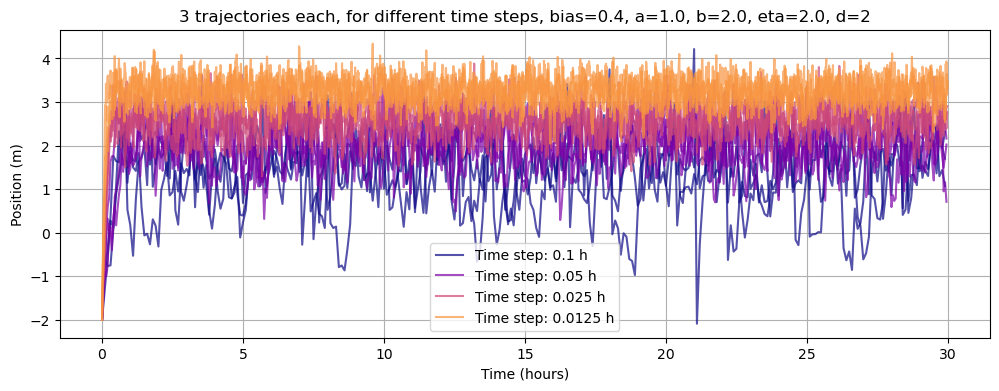

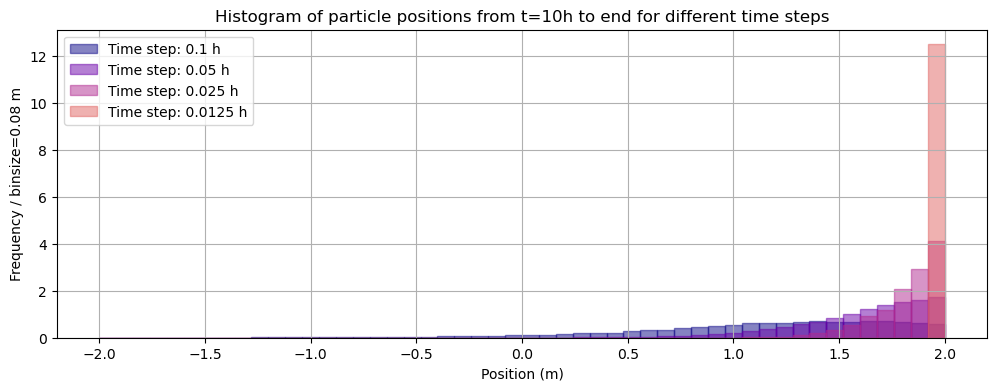

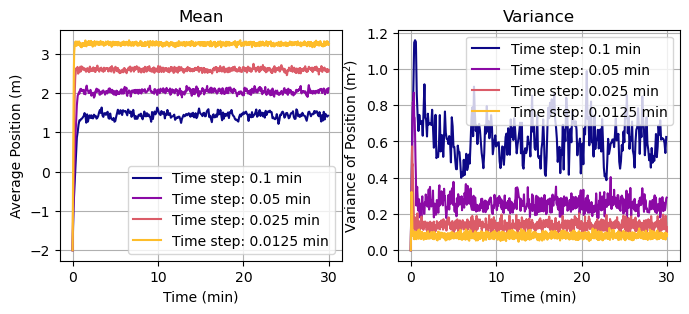

In [9]:
#plot 3 trajectories for each time step
fig,ax=plt.subplots(figsize=(12, 4))
for it,t_step in enumerate(t_step_array):
    for i in range(3):
        ax.plot(time_array[it], positions[it][i], c=plt.cm.plasma(it/4),alpha=0.7,label=f'Time step: {t_step} h' if i == 0 else "")
ax.set_title(f'3 trajectories each, for different time steps, bias={bias}, a={a}, b={b}, eta={eta}, d={d}')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Position (m)')
ax.legend()
ax.grid()



#plot histogram from t=10 until end of positions for each time step
min=-2
max=2
n_bins=50
binsize=(max-min)/n_bins
t_stable=10

fig,ax=plt.subplots(figsize=(12, 4))
for it,t_step in enumerate(t_step_array):
    
    ax.hist(positions[it][:, int(t_stable/t_step):].flatten(), bins=50, range=(min, max), density=True, alpha=0.5, edgecolor=plt.cm.plasma(it/5),color=plt.cm.plasma(it/5), label=f'Time step: {t_step} h')
ax.set_title(f'Histogram of particle positions from t={t_stable}h to end for different time steps')
ax.set_xlabel('Position (m)')
ax.set_ylabel(f'Frequency / binsize={binsize:.2f} m')
ax.legend()
ax.grid()



#plot average position over time for each time step and variance of position over time for each time step
fig,ax=plt.subplots(1,2, figsize=(8, 3))
for it,t_step in enumerate(t_step_array):
    ax[0].plot(time_array[it], positions[it].mean(axis=0), c=plt.cm.plasma(it/3.5), label=f'Time step: {t_step} min')
    ax[1].plot(time_array[it], positions[it].var(axis=0), c=plt.cm.plasma(it/3.5), label=f'Time step: {t_step} min')
ax[0].set_title(f'Mean')
ax[0].set_xlabel('Time (min)')
ax[0].set_ylabel('Average Position (m)')
ax[0].legend()
ax[0].grid()
ax[1].set_title(f'Variance')
ax[1].set_xlabel('Time (min)')
ax[1].set_ylabel('Variance of Position (m$^2$)')
ax[1].legend()
ax[1].grid()
fig.savefig('average_variance_errorcode.png')